<a href="https://colab.research.google.com/github/utkrasht23/UAPOML/blob/main/UAPOML_ASS_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ==========================================
# Setup and Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     TimeSeriesSplit, GridSearchCV, cross_val_predict)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             average_precision_score, precision_recall_curve,
                             mean_squared_error, r2_score)
from sklearn.linear_model import LogisticRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              StackingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier, plot_importance

# Set global random state
RANDOM_STATE = 42

# 1.1

--- 1.1 Logistic Regression ---
Accuracy: 0.9338 | Precision: 0.5593
Recall: 0.0439 | F1: 0.0814 | AUC: 0.7151


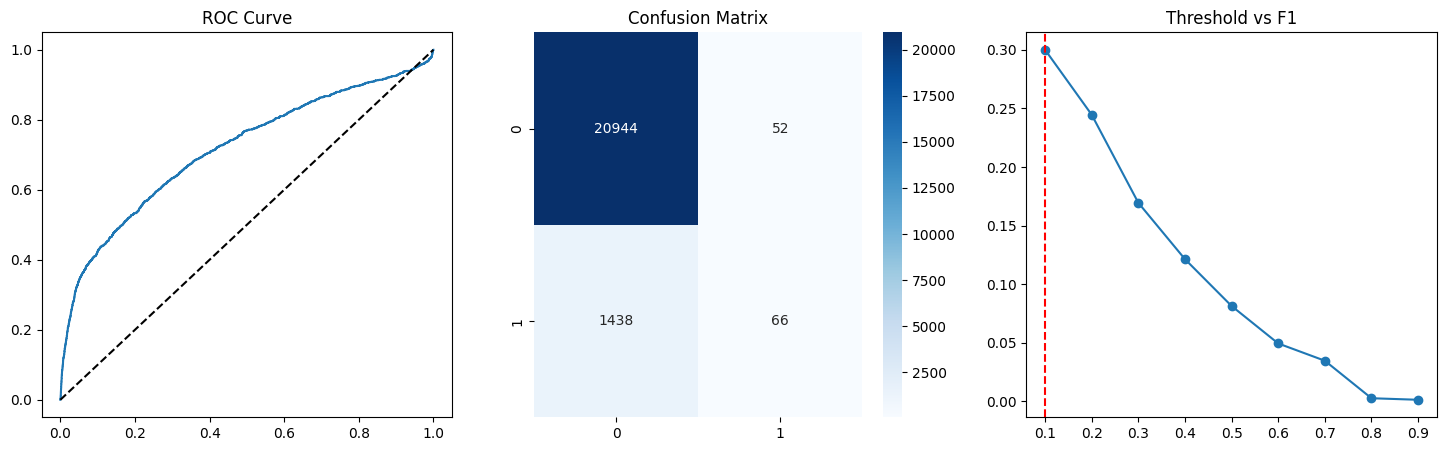

Top 5 Features:
 NumberOfTime60-89DaysPastDueNotWorse    3.768298
NumberOfTime30-59DaysPastDueNotWorse    2.037825
NumberOfTimes90DaysLate                 1.889931
age                                     0.403893
MonthlyIncome                           0.402737
dtype: float64


In [12]:
# ==========================================
# 1.1 Logistic Regression
# ==========================================
print("--- 1.1 Logistic Regression ---")
df_credit = pd.read_csv('cs-training.csv')

# Preprocessing
df_credit['MonthlyIncome'].fillna(df_credit['MonthlyIncome'].median(), inplace=True)
df_credit['NumberOfDependents'].fillna(df_credit['NumberOfDependents'].median(), inplace=True)
X = df_credit.drop('SeriousDlqin2yrs', axis=1)
y = df_credit['SeriousDlqin2yrs']

# 70/15/15 Stratified Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=RANDOM_STATE)

# Standardise
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train & Evaluate
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f} | Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Plots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[0].plot(fpr, tpr); ax[0].plot([0, 1], [0, 1], 'k--'); ax[0].set_title('ROC Curve')
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[1]); ax[1].set_title('Confusion Matrix')

thresholds = np.arange(0.1, 1.0, 0.1)
f1s = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]
ax[2].plot(thresholds, f1s, marker='o'); ax[2].axvline(thresholds[np.argmax(f1s)], color='r', ls='--'); ax[2].set_title('Threshold vs F1')
plt.show()

# Top 5 features
top_5 = pd.Series(log_reg.coef_[0], index=X.columns).abs().nlargest(5)
print("Top 5 Features:\n", top_5)

# 1.2


--- 1.2 Decision Tree ---
Unpruned Train: 1.0000 | Test: 0.6522


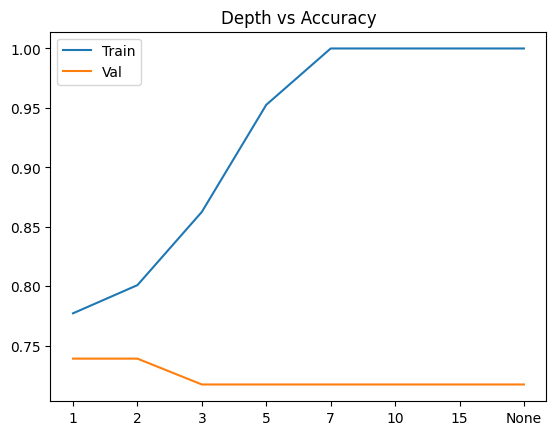

Best CCP Alpha: 0.0312 | Test AUC: 0.7000


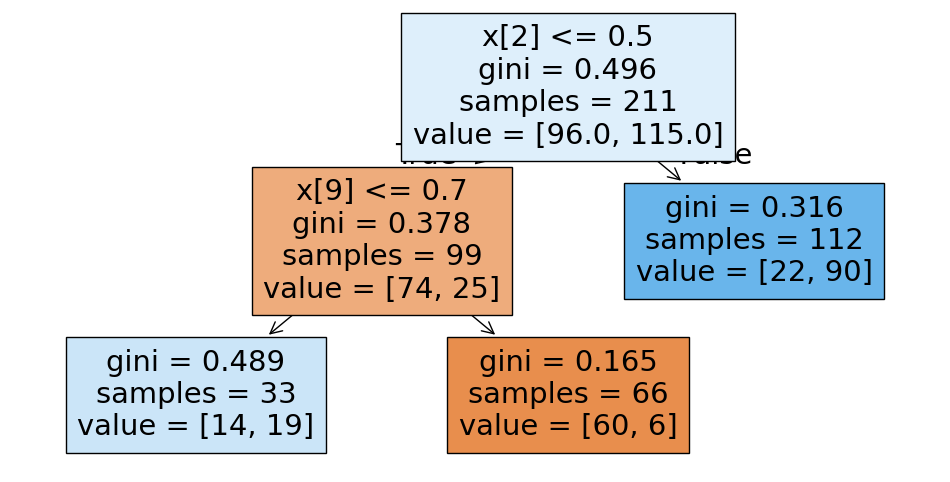

In [13]:
# ==========================================
# 1.2 Decision Tree
# ==========================================
print("\n--- 1.2 Decision Tree ---")
df_heart = pd.read_csv('heart.csv')
X_h = df_heart.drop('target', axis=1); y_h = df_heart['target']

X_h_temp, X_h_test, y_h_temp, y_h_test = train_test_split(X_h, y_h, test_size=0.15, stratify=y_h, random_state=RANDOM_STATE)
X_h_train, X_h_val, y_h_train, y_h_val = train_test_split(X_h_temp, y_h_temp, test_size=0.15/0.85, stratify=y_h_temp, random_state=RANDOM_STATE)

# Unpruned
dt_unpruned = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_h_train, y_h_train)
print(f"Unpruned Train: {dt_unpruned.score(X_h_train, y_h_train):.4f} | Test: {dt_unpruned.score(X_h_test, y_h_test):.4f}")

# Depth Tuning
depths = [1, 2, 3, 5, 7, 10, 15, None]
t_acc, v_acc = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_h_train, y_h_train)
    t_acc.append(dt.score(X_h_train, y_h_train)); v_acc.append(dt.score(X_h_val, y_h_val))

plt.plot([str(d) for d in depths], t_acc, label='Train'); plt.plot([str(d) for d in depths], v_acc, label='Val')
plt.title('Depth vs Accuracy'); plt.legend(); plt.show()

# Cost-Complexity Pruning
path = dt_unpruned.cost_complexity_pruning_path(X_h_train, y_h_train)
best_alpha, best_auc = 0, 0
for alpha in path.ccp_alphas:
    dt = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha).fit(X_h_train, y_h_train)
    auc = roc_auc_score(y_h_val, dt.predict_proba(X_h_val)[:, 1])
    if auc > best_auc: best_auc, best_alpha = auc, alpha

best_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=best_alpha).fit(X_h_train, y_h_train)
print(f"Best CCP Alpha: {best_alpha:.4f} | Test AUC: {roc_auc_score(y_h_test, best_tree.predict_proba(X_h_test)[:, 1]):.4f}")

plt.figure(figsize=(12, 6)); plot_tree(best_tree, max_depth=4, filled=True); plt.show()

# 2.1


--- 2.1 Regularised Regression ---
Ridge | Lambda: 429.1934 | Non-Zero: 227 | RMSE: 27393.03 | R2: 0.8878
Lasso | Lambda: 0.0054 | Non-Zero: 81 | RMSE: 26721.40 | R2: 0.8917
ElasticNet | Lambda: 0.0687 | Non-Zero: 74 | RMSE: 28203.20 | R2: 0.8877


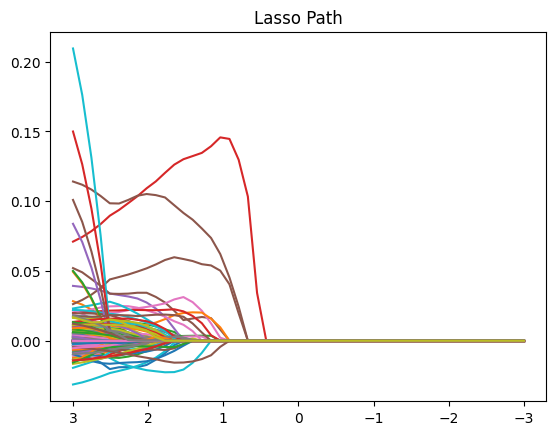

In [14]:
# ==========================================
# 2.1 Regularised Regression
# ==========================================
print("\n--- 2.1 Regularised Regression ---")
df_house = pd.read_csv('train.csv')
y_reg = np.log1p(df_house['SalePrice']); X_reg = df_house.drop(['SalePrice', 'Id'], axis=1)

X_reg.dropna(thresh=len(X_reg)*0.6, axis=1, inplace=True)
for col in X_reg.select_dtypes(include=np.number).columns: X_reg[col].fillna(X_reg[col].median(), inplace=True)
for col in X_reg.select_dtypes(exclude=np.number).columns: X_reg[col].fillna(X_reg[col].mode()[0], inplace=True)
X_reg = pd.get_dummies(X_reg, drop_first=True)

X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)
scaler_r = StandardScaler(); X_r_train_s = scaler_r.fit_transform(X_r_train); X_r_test_s = scaler_r.transform(X_r_test)

alphas = np.logspace(-3, 3, 50)
models = {
    'Ridge': RidgeCV(alphas=alphas, cv=5).fit(X_r_train_s, y_r_train),
    'Lasso': LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE).fit(X_r_train_s, y_r_train),
    'ElasticNet': ElasticNetCV(l1_ratio=[0.1,0.5,0.7,0.9,0.95,1.0], alphas=alphas, cv=5, random_state=RANDOM_STATE).fit(X_r_train_s, y_r_train)
}

for name, model in models.items():
    preds = model.predict(X_r_test_s)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_r_test), np.expm1(preds)))
    print(f"{name} | Lambda: {model.alpha_:.4f} | Non-Zero: {np.sum(model.coef_ != 0)} | RMSE: {rmse:.2f} | R2: {r2_score(y_r_test, preds):.4f}")

_, coefs_lasso, _ = models['Lasso'].path(X_r_train_s, y_r_train, alphas=alphas)
plt.plot(np.log10(alphas), coefs_lasso.T); plt.gca().invert_xaxis(); plt.title('Lasso Path'); plt.show()

# 2.2

In [15]:
# ==========================================
# 2.2 Locally Weighted Regression
# ==========================================
print("\n--- 2.2 LWR ---")
df_housing = pd.read_csv('housing.csv').dropna().sample(2000, random_state=RANDOM_STATE)
X_lwr = df_housing[['median_income']].values; y_lwr = df_housing['median_house_value'].values
X_l_tr, X_l_te, y_l_tr, y_l_te = train_test_split(X_lwr, y_lwr, test_size=0.3, random_state=RANDOM_STATE)

def lwr_predict(X_t, y_t, x_q, tau):
    X_b = np.c_[np.ones(X_t.shape[0]), X_t]; x_qb = np.r_[1, x_q]
    W = np.diag(np.exp(-np.sum((X_t - x_q)**2, axis=1) / (2 * tau**2)))
    theta = np.linalg.inv(X_b.T @ W @ X_b + 1e-8*np.eye(X_b.shape[1])) @ X_b.T @ W @ y_t
    return x_qb @ theta

for tau in [0.05, 0.1, 0.3, 1.0, 3.0]:
    preds = [lwr_predict(X_l_tr, y_l_tr, x, tau) for x in X_l_te]
    print(f"Tau: {tau} | Test RMSE: {np.sqrt(mean_squared_error(y_l_te, preds)):.2f}")

# Compare to OLS (tau -> infinity)
from sklearn.linear_model import LinearRegression
ols = LinearRegression().fit(X_l_tr, y_l_tr)
print(f"OLS Test RMSE: {np.sqrt(mean_squared_error(y_l_te, ols.predict(X_l_te))):.2f}")


--- 2.2 LWR ---
Tau: 0.05 | Test RMSE: 95370.02
Tau: 0.1 | Test RMSE: 102821.70
Tau: 0.3 | Test RMSE: 92454.65
Tau: 1.0 | Test RMSE: 91891.47
Tau: 3.0 | Test RMSE: 92165.57
OLS Test RMSE: 92238.61


# 3.1


--- 3.1 Random Forest ---
OOB Score: 0.9728 | Test AUC: 0.8833


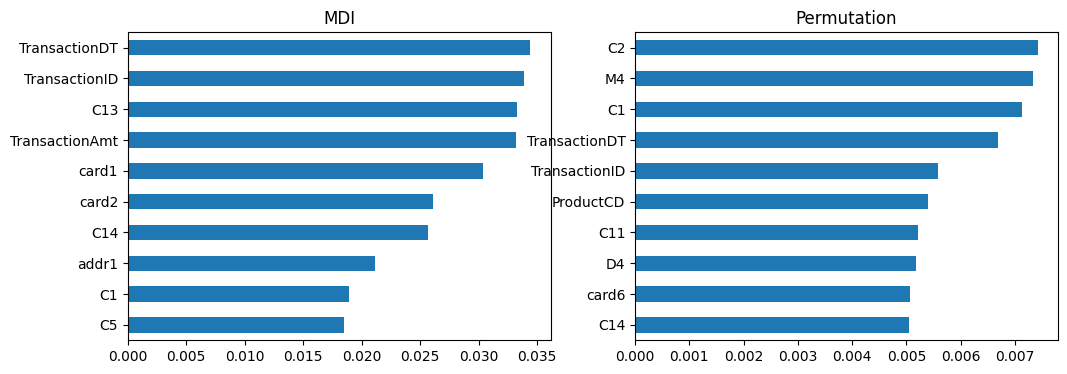

In [16]:
# ==========================================
# 3.1 Random Forest
# ==========================================
print("\n--- 3.1 Random Forest ---")
df_fraud = pd.read_csv('train_transaction.csv').sample(50000, random_state=RANDOM_STATE)
X_f = df_fraud.drop('isFraud', axis=1); y_f = df_fraud['isFraud']

X_f.dropna(thresh=len(X_f)*0.5, axis=1, inplace=True)
for col in X_f.select_dtypes(include=['object']).columns: X_f[col] = X_f[col].astype('category').cat.codes
X_f.fillna(X_f.median(), inplace=True)

X_t, X_te, y_t, y_te = train_test_split(X_f, y_f, test_size=0.15, stratify=y_f, random_state=RANDOM_STATE)
X_tr, X_v, y_tr, y_v = train_test_split(X_t, y_t, test_size=0.15/0.85, stratify=y_t, random_state=RANDOM_STATE)

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', oob_score=True, random_state=RANDOM_STATE, n_jobs=-1).fit(X_tr, y_tr)
print(f"OOB Score: {rf.oob_score_:.4f} | Test AUC: {roc_auc_score(y_te, rf.predict_proba(X_te)[:,1]):.4f}")

# MDI vs Permutation
mdi = pd.Series(rf.feature_importances_, index=X_tr.columns).nlargest(10)
perm = permutation_importance(rf, X_v, y_v, scoring='roc_auc', n_repeats=5, random_state=RANDOM_STATE)
p_imp = pd.Series(perm.importances_mean, index=X_tr.columns).nlargest(10)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
mdi.sort_values().plot(kind='barh', ax=ax[0], title='MDI')
p_imp.sort_values().plot(kind='barh', ax=ax[1], title='Permutation'); plt.show()

# 3.2


--- 3.2 XGBoost ---
XGB Test AUC: 0.5002 | AP: 0.5671


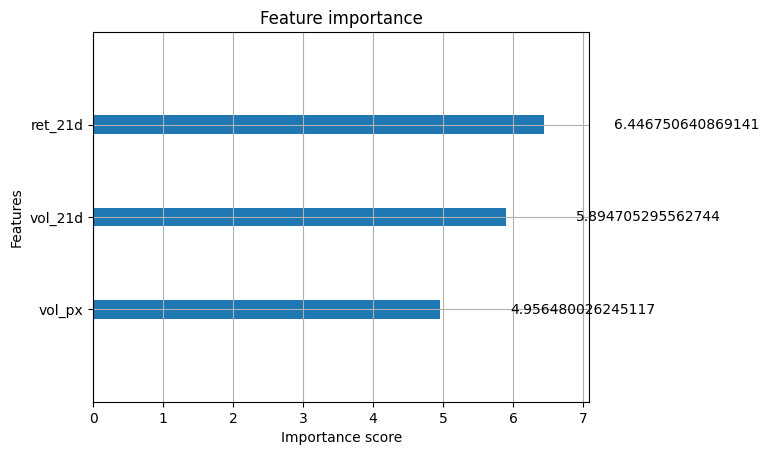

In [17]:
# ==========================================
# 3.2 XGBoost Time Series
# ==========================================
print("\n--- 3.2 XGBoost ---")
df_stock = pd.read_csv('all_stocks_5yr.csv').sort_values(by=['Name', 'date'])

# Rolling Features
df_stock['ret_21d'] = df_stock.groupby('Name')['close'].pct_change(21)
df_stock['vol_21d'] = df_stock.groupby('Name')['close'].pct_change(1).rolling(21).std()
df_stock['vol_px'] = df_stock['volume'] / df_stock['close']
df_stock['target'] = (df_stock.groupby('Name')['close'].pct_change(21).shift(-21) > 0).astype(int)
df_clean = df_stock.dropna().copy()

# Time Split
train = df_clean[df_clean['date'] < '2016-07-01']
val = df_clean[(df_clean['date'] >= '2016-07-01') & (df_clean['date'] < '2017-01-01')]
test = df_clean[df_clean['date'] >= '2017-01-01']

features = ['ret_21d', 'vol_21d', 'vol_px']
X_tr, y_tr = train[features], train['target']
X_v, y_v = val[features], val['target']
X_te, y_te = test[features], test['target']

xgb = XGBClassifier(max_depth=5, learning_rate=0.05, subsample=0.8, n_estimators=500, eval_metric='auc', random_state=RANDOM_STATE)
xgb.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)

preds = xgb.predict_proba(X_te)[:, 1]
print(f"XGB Test AUC: {roc_auc_score(y_te, preds):.4f} | AP: {average_precision_score(y_te, preds):.4f}")
plot_importance(xgb, importance_type='gain'); plt.show()

# 4.1


--- 4.1 Bias-Variance ---
    Model     Bias2       Var     Total
0  LogReg  0.144467  0.003507  0.147974
1   Stump  0.165246  0.017549  0.182795
2    Tree  0.150424  0.145680  0.296104
3      RF  0.149881  0.007030  0.156911


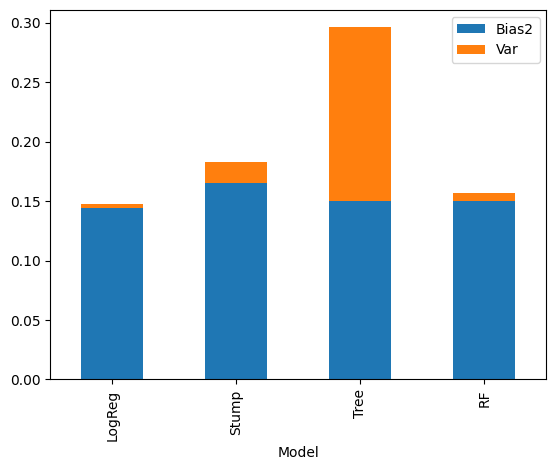

In [18]:
# ==========================================
# 4.1 Bias-Variance
# ==========================================
print("\n--- 4.1 Bias-Variance ---")
df_diab = pd.read_csv('diabetes.csv')
X_d, y_d = df_diab.drop('Outcome', axis=1).values, df_diab['Outcome'].values
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(X_d, y_d, test_size=0.3, random_state=4)

models = {
    'LogReg': LogisticRegression(max_iter=1000), 'Stump': DecisionTreeClassifier(max_depth=1),
    'Tree': DecisionTreeClassifier(max_depth=None), 'RF': RandomForestClassifier(n_estimators=100)
}

res = []
for name, model in models.items():
    preds = np.zeros((50, len(y_d_te)))
    for b in range(50):
        idx = np.random.choice(len(X_d_tr), len(X_d_tr), replace=True)
        model.fit(X_d_tr[idx], y_d_tr[idx])
        preds[b, :] = model.predict_proba(X_d_te)[:, 1]

    exp_preds = np.mean(preds, axis=0)
    bias2 = np.mean((exp_preds - y_d_te)**2)
    var = np.mean(np.var(preds, axis=0))
    res.append({'Model': name, 'Bias2': bias2, 'Var': var, 'Total': bias2+var})

df_bv = pd.DataFrame(res)
print(df_bv)
df_bv.set_index('Model')[['Bias2', 'Var']].plot(kind='bar', stacked=True); plt.show()

# 5.1

In [21]:
import pandas as pd
import zipfile
import os

# 1. Extract the zip file
zip_path = 'archive.zip' # Update this if your zip file has a different name
extract_dir = 'nifty50_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# 2. Find all CSVs in the extracted folder
csv_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

# 3. Read and combine them into one DataFrame
df_list = []
for file in csv_files:
    file_path = os.path.join(extract_dir, file)
    temp_df = pd.read_csv(file_path)

    # Optional: If the dataset doesn't have a 'Name' or 'Symbol' column,
    # we can use the filename (without .csv) as the stock ticker.
    if 'Symbol' not in temp_df.columns and 'Name' not in temp_df.columns:
        temp_df['Name'] = file.replace('.csv', '')

    df_list.append(temp_df)

# Combine everything
df_nifty_combined = pd.concat(df_list, ignore_index=True)

# 4. Save it as a single CSV for easy access later
df_nifty_combined.to_csv('nifty50_combined.csv', index=False)

print(f"Successfully combined {len(csv_files)} files.")
print(f"Total rows: {len(df_nifty_combined)}")

Successfully combined 52 files.
Total rows: 470434



--- 5.1 Gradient Boosting ---
Engineering portfolio features safely...
Data cleaning successful! Remaining usable rows for training: 454074
Running Expanding-Window Cross Validation...
Best GB Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Test AUC: 0.5214
Estimating ensemble disagreement uncertainty...


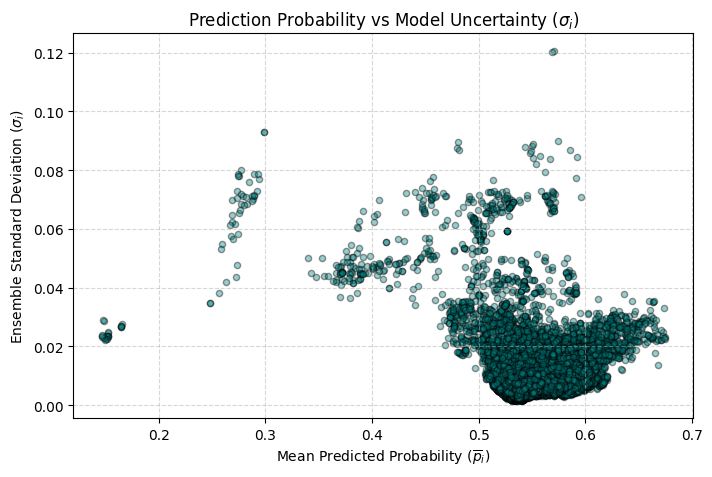

In [27]:
# ==========================================
# 5.1 Gradient Boosting (Uncertainty) - FIXED
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

print("\n--- 5.1 Gradient Boosting ---")

# Load your combined NIFTY dataset
df_nifty = pd.read_csv('nifty50.csv')

# Standardise column names to lowercase
df_nifty.columns = df_nifty.columns.str.lower()
if 'symbol' in df_nifty.columns and 'name' not in df_nifty.columns:
    df_nifty.rename(columns={'symbol': 'name'}, inplace=True)

# Ensure data is strictly sorted by stock name and date to protect rolling windows
df_nifty['date'] = pd.to_datetime(df_nifty['date'])
df_nifty = df_nifty.sort_values(by=['name', 'date']).reset_index(drop=True)

print("Engineering portfolio features safely...")

# Basic Rolling Returns
df_nifty['ret_5d'] = df_nifty.groupby('name')['close'].pct_change(5)
df_nifty['ret_21d'] = df_nifty.groupby('name')['close'].pct_change(21)
df_nifty['ret_63d'] = df_nifty.groupby('name')['close'].pct_change(63)

# Volatility (Computed INSIDE the group to prevent cross-stock leakage)
df_nifty['vol_21d'] = df_nifty.groupby('name')['close'].transform(lambda x: x.pct_change().rolling(21).std())
df_nifty['vol_63d'] = df_nifty.groupby('name')['close'].transform(lambda x: x.pct_change().rolling(63).std())

# 52-Week High / Low Price Relatives (Using transform to guarantee perfect index alignment)
df_nifty['px_52w_high'] = df_nifty['close'] / df_nifty.groupby('name')['close'].transform(lambda x: x.rolling(252).max())
df_nifty['px_52w_low'] = df_nifty['close'] / df_nifty.groupby('name')['close'].transform(lambda x: x.rolling(252).min())

# Volume Z-Score
df_nifty['vol_z'] = df_nifty.groupby('name')['volume'].transform(lambda x: (x - x.rolling(21).mean()) / x.rolling(21).std())

# Target: 21-day forward return > 0 (shifted backwards by 21 days)
df_nifty['target'] = df_nifty.groupby('name')['close'].transform(lambda x: (x.pct_change(21).shift(-21) > 0).astype(int))

# Define the exact features required by the prompt
features = ['ret_5d', 'ret_21d', 'ret_63d', 'vol_21d', 'vol_63d', 'px_52w_high', 'px_52w_low', 'vol_z']

# CRITICAL FIX: Only drop rows where OUR features or target are NaN
df_n = df_nifty.dropna(subset=features + ['target']).copy()

print(f"Data cleaning successful! Remaining usable rows for training: {len(df_n)}")

# Temporal split (80% Train, 20% Test)
split_idx = int(len(df_n) * 0.8)
X_n = df_n[features]
y_n = df_n['target']

X_n_tr, X_n_te = X_n.iloc[:split_idx], X_n.iloc[split_idx:]
y_n_tr, y_n_te = y_n.iloc[:split_idx], y_n.iloc[split_idx:]

# Expanding Window CV
tscv = TimeSeriesSplit(n_splits=3)
gbc = GradientBoostingClassifier(random_state=42)
grid = GridSearchCV(gbc, {'max_depth': [2, 3], 'learning_rate': [0.05, 0.1], 'n_estimators': [100]}, cv=tscv, scoring='roc_auc')

print("Running Expanding-Window Cross Validation...")
grid.fit(X_n_tr, y_n_tr)

best_gbc = grid.best_estimator_
print(f"Best GB Params: {grid.best_params_}")
print(f"Test AUC: {roc_auc_score(y_n_te, best_gbc.predict_proba(X_n_te)[:,1]):.4f}")

# Uncertainty via Ensemble Disagreement (M=20)
print("Estimating ensemble disagreement uncertainty...")
M = 20
preds_m = np.zeros((M, len(y_n_te)))
for m in range(M):
    idx = np.random.choice(len(X_n_tr), len(X_n_tr), replace=True)
    model = GradientBoostingClassifier(**grid.best_params_, random_state=m).fit(X_n_tr.iloc[idx], y_n_tr.iloc[idx])
    preds_m[m, :] = model.predict_proba(X_n_te)[:, 1]

mean_p = np.mean(preds_m, axis=0)
std_p = np.std(preds_m, axis=0)

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(mean_p, std_p, alpha=0.4, color='teal', edgecolor='k', s=20)
plt.title("Prediction Probability vs Model Uncertainty ($\sigma_i$)")
plt.xlabel("Mean Predicted Probability ($\overline{p}_i$)")
plt.ylabel("Ensemble Standard Deviation ($\sigma_i$)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()